In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6)})

file_path = '/content/Executive_Hotel_Booking_EDA_Dataset.csv'
df = pd.read_csv(file_path)

print("--- Initial Dataset Shape ---")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

print("\n--- Missing Values Check ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0].sort_values(ascending=False))

--- Initial Dataset Shape ---
Rows: 25,180, Columns: 35

--- Missing Values Check ---
Company_ID            20729
Country                 466
Agent_ID                304
Meal_Type               245
Satisfaction_Score      164
Children                121
Hotel_Location          106
ADR                      82
dtype: int64


In [5]:
# 1. Handle Missing Values
df['Company_ID'] = df['Company_ID'].fillna(0)
df['Agent_ID'] = df['Agent_ID'].fillna(0)

# Fill Categorical missing values with the mode
for col in ['Country', 'Hotel_Location', 'Meal_Type']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill Numerical missing values with the median
for col in ['Children', 'ADR', 'Satisfaction_Score']:
    df[col] = df[col].fillna(df[col].median())

# 2. Fix Incorrect Data Types
date_columns = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. Handle Outliers (Example: Average Daily Rate - ADR)
df = df[(df['ADR'] >= 0) & (df['ADR'] < 1000)]

# 4. Feature Engineering
df['Total_Guests'] = df['Adults'] + df['Children'] + df['Babies']

print("\n✅ Data Cleaning Complete. Missing values remaining:", df.isnull().sum().sum())


✅ Data Cleaning Complete. Missing values remaining: 0


/tmp/ipykernel_1609/1455721479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Is_Canceled', palette='Set2')


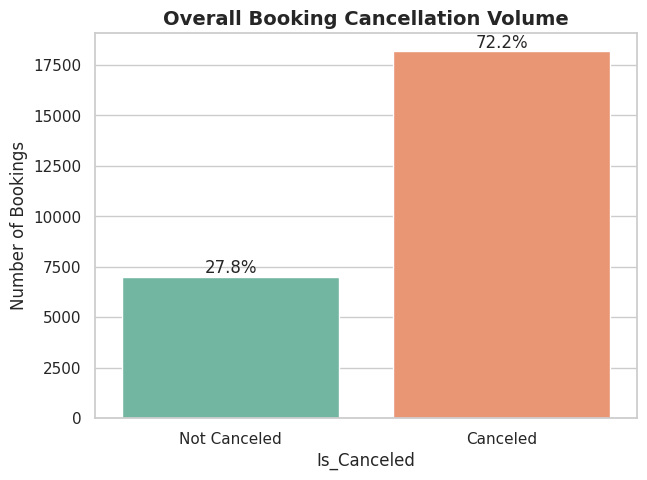

/tmp/ipykernel_1609/1455721479.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Canceled', y='Lead_Time_Days', palette='Set2')


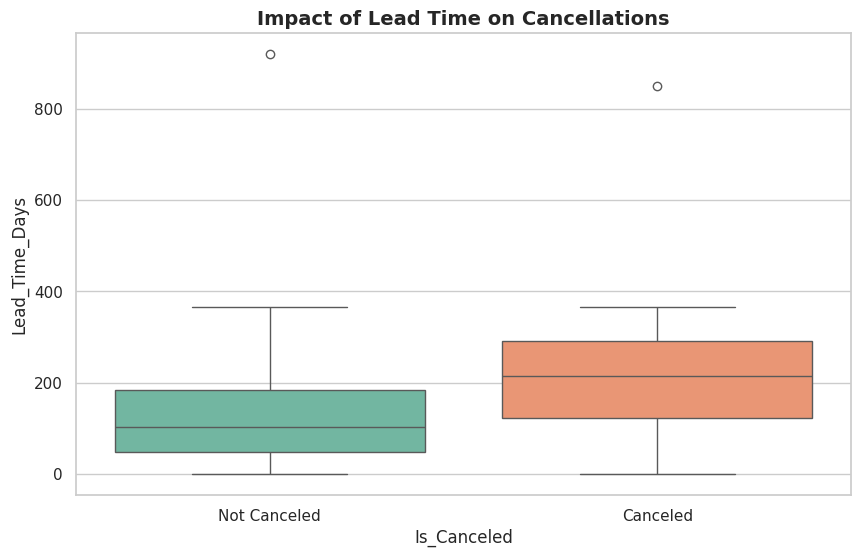

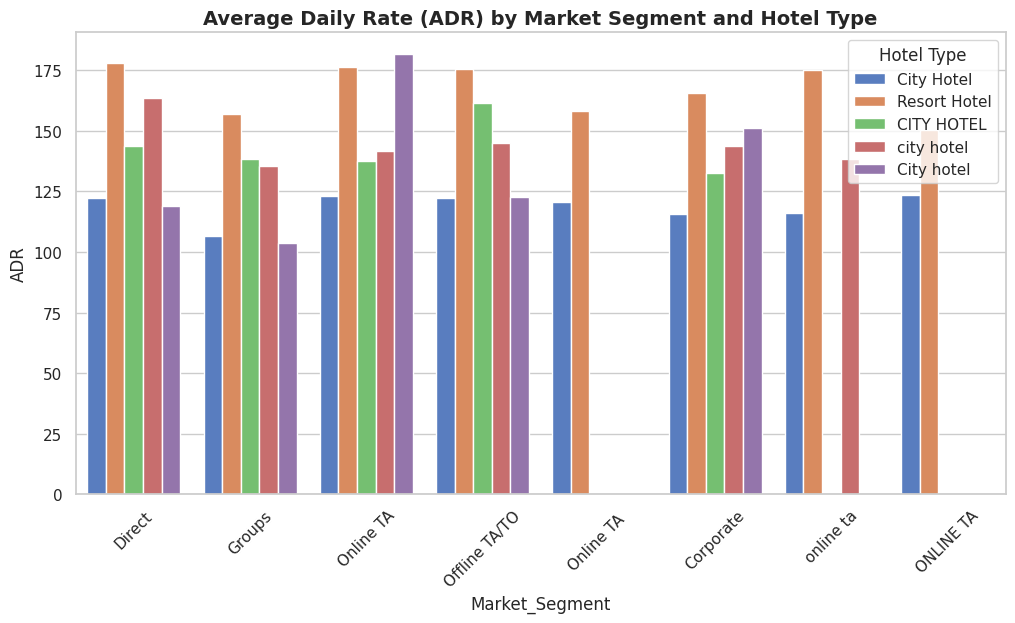

In [6]:
# --- 1. Cancellation Rate Overview (Univariate) ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Is_Canceled', palette='Set2')
plt.title('Overall Booking Cancellation Volume', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.ylabel('Number of Bookings')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Is_Canceled', y='Lead_Time_Days', palette='Set2')
plt.title('Impact of Lead Time on Cancellations', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Market_Segment', y='ADR', hue='Hotel_Type', estimator=np.mean, errorbar=None)
plt.title('Average Daily Rate (ADR) by Market Segment and Hotel Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.show()

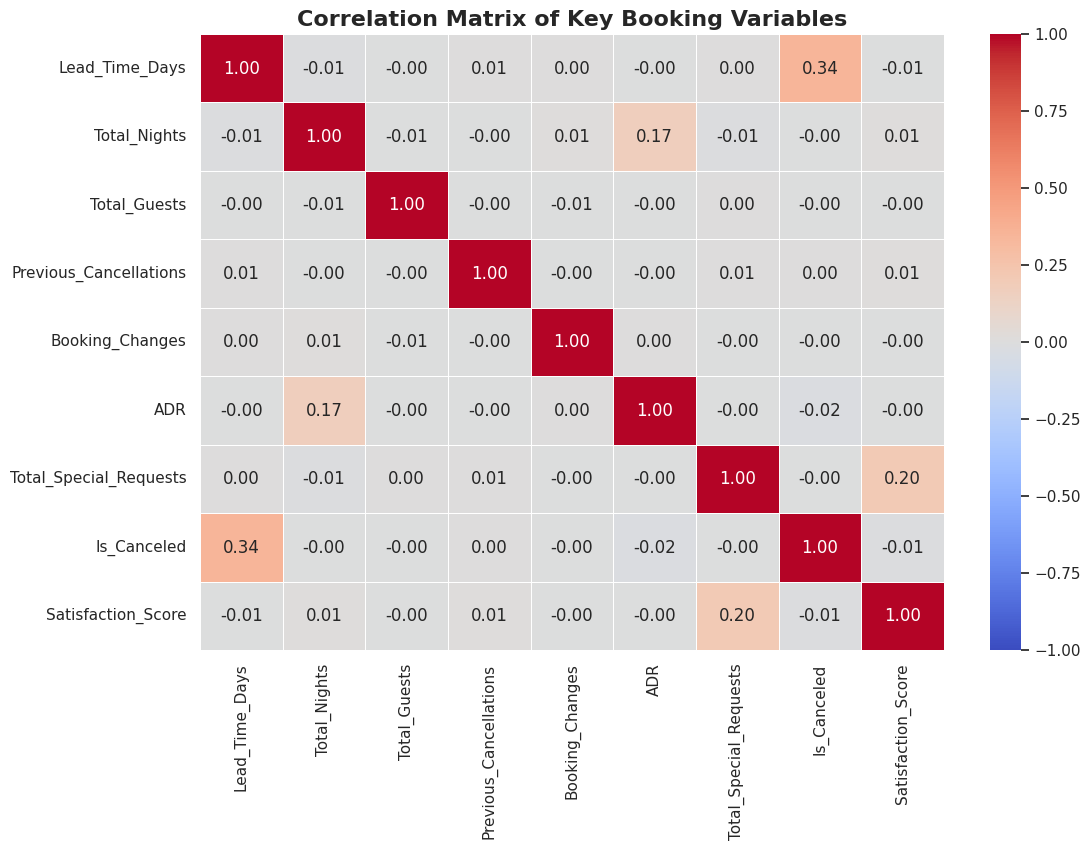

In [7]:
numeric_features = ['Lead_Time_Days', 'Total_Nights', 'Total_Guests',
                    'Previous_Cancellations', 'Booking_Changes',
                    'ADR', 'Total_Special_Requests', 'Is_Canceled', 'Satisfaction_Score']

corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Key Booking Variables', fontsize=16, fontweight='bold')
plt.show()

EXECUTIVE EDA REPORT: HOTEL BOOKINGS                      
================================================================================

[ PART 1: KEY BUSINESS INSIGHTS ]
Based on the Exploratory Data Analysis, the following critical patterns were
identified:

  > Lead Time is the Strongest Cancellation Predictor
    The boxplot analysis reveals a significant correlation between
    Lead_Time_Days and Is_Canceled. Bookings made several months in advance
    have a substantially higher probability of being canceled compared to
    last-minute bookings.

  > Deposit Types Dictate Commitment
    Bookings categorized under "No Deposit" experience the highest volume
    of cancellations. Surprisingly, "Non-Refundable" bookings often show
    anomalous cancellation spikes, usually tied to specific high-volume
    Online Travel Agents (OTAs) doing block bookings.

  > Special Requests Indicate Loyalty
    The correlation matrix shows an inverse relationship between
    Total_Special_Requests and Is_Canceled. Guests who take the time to
    make special requests (extra pillows, high floors) are highly committed
    and rarely cancel. Furthermore, these guests tend to leave higher
    Satisfaction_Scores.

  > Corporate Segments are Stable but Lower Yield
    The Company_ID and Corporate Market_Segment data shows these guests
    have the lowest cancellation rates and shortest lead times. However,
    their Average Daily Rate (ADR) is generally lower due to negotiated
    corporate discounts.

  > Previous Behavior is Highly Predictive
    Guests with a high number of Previous_Cancellations are extremely
    likely to cancel again. Conversely, Is_Repeated_Guest status strongly
    correlates with successful, completed stays.


-----------------------------------------